## Setup

In [1]:
# Core libraries
from openai import OpenAI
from tqdm import trange
import pandas as pd
import time
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Connect to the provider
client = OpenAI(
    base_url="https://api.deepinfra.com/v1/openai",
    api_key="tQ9NcgoVBuIQYplJ1yyMtaTMAUTFqQ0o",  # Replace with your own key
)

# Choose your model, temperature, and return tokens
llm = 'moonshotai/Kimi-K2-Instruct-0905'
temp = 0.7
max_length = 10

# Load the data
data = pd.read_csv(
    "/content/khandcoding.csv"
)

# Make sure the gold labels are numeric
data["afford_ed"] = data["afford_ed"].astype(int)

print(data["afford_ed"].value_counts())
data.head(10)

afford_ed
0    182
1     18
Name: count, dtype: int64


,basepk,speechdate,maintopic,subtopic,subsubtopic,speakerparty,speakerriding,speakername,speech_date,year,...,speechmonth,clean_text,indig_ed,lang_ed,afford_ed,univ_ed,skills_ed,elc_ed,fed_ed,Unnamed: 22
0,370619,1913-05-23,SUPPLY.,NaN,NaN,Conservative (1867-1942),NaN,John Douglas Hazen,1913-05-23,1913,...,1913-05-01,"At present there are.chools at Yarmouth, N.. N...",0,0,0,0,1,0.0,0,NaN
1,1031367,1934-05-17,MARKETING ACT,ORGANIZATION TO IMPROVE METHODS AND PRACTICES ...,NaN,Liberal,NaN,John Campbell Elliott,1934-05-17,1934,...,1934-05-01,I wish to call the minister's attention to a s...,0,0,0,0,0,0.0,0,NaN
2,3694840,1987-10-08,GOVERNMENT ORDERS,"THE CONSTITUTION ACT, 1867 CONSTITUTION AMENDM...",NaN,Liberal,NaN,David Berger,1987-10-08,1987,...,1987-10-01,"Mr.Speaker, the Member for Eglinton Lawrence (...",0,1,0,0,0,0.0,0,NaN
3,610687,1921-05-18,QUESTIONS,REVISED EDITION. COMMONS,NaN,Liberal,NaN,George Newcombe Gordon,1921-05-18,1921,...,1921-05-01,"They are capable of.mploying and do employ, I ...",0,0,0,0,0,0.0,0,NaN
4,4312759,2005-09-28,Statements by Members,Jacqueline Perry,NaN,Liberal,Brant,Lloyd St. Amand,2005-09-28,2005,...,2005-09-01,"Mr.Speaker, I rise today to pay tribute to a t...",0,0,0,0,0,0.0,0,NaN
5,4225477,2002-10-07,Government Orders,Committee Business and Reinstatement of Govern...,NaN,Liberal,Ancaster--Dundas--Flamborough--Aldershot,John Bryden,2002-10-07,2002,...,2002-10-01,"Mr.Speaker, we are debating today a motion tha...",0,0,0,0,0,0.0,0,NaN
6,1109388,1937-01-19,DEPARTMENT OF PENSIONS AND NATIONAL HEALTH,NaN,NaN,Conservative (1867-1942),NaN,Richard Bedford Bennett,1937-01-19,1937,...,1937-01-01,Precisely; because it is the kind of effort th...,0,0,0,0,0,0.0,0,NaN
7,3375532,1982-07-09,ORAL QUESTION PERIOD,REGIONAL DEVELOPMENT,PRINCE EDWARD ISLAND CONSTRUCTION PROJECTS,Liberal,NaN,Lloyd Axworthy,1982-07-09,1982,...,1982-07-01,"Madam Speaker, again I want to correct the imp...",0,0,0,0,1,0.0,0,NaN
8,2974544,1975-06-04,GOVERNMENT ORDERS,REMOVAL OF PROVISION ALLOWING DEDUCTION OF EXP...,NaN,Progressive Conservative,NaN,Robert Carman Coates,1975-06-04,1975,...,1975-06-01,We must thank the government for bringing forw...,0,0,0,0,0,0.0,0,NaN
9,676242,1923-06-22,"DAIRY INDUSTRY ACT, 1914. AMENDMENT",NaN,NaN,Conservative (1867-1942),NaN,Simon Fraser Tolmie,1923-06-22,1923,...,1923-06-01,"With regard to clause 2.f this resolution, I m...",0,0,0,0,0,0.0,0,NaN


In [2]:
# Prompt used across all three approaches
prompt = """
Please classify the following sentence as either:
- 1 = Is about affordable Education
- 0 = Is not about affordable Education

Note:
Affordable education excerpt discusses the affordability of college, university,
 or other postsecondary study, including tuition, student debt, grants, loans,
  repayment assistance, financial barriers, access to higher education, or
  unequal opportunities to attend postsecondary institutions.

Example:
The bill deals with a single matter, that of grants for university education.

Return only one character: 0 or 1.
""".strip()


In [3]:
def clean_prediction(x):
    """Clean model output and keep only valid labels."""
    if x is None:
        return None

    x = str(x).strip().replace("'", "").replace('"', "")
    if x in {"0", "1"}:
        return x
    return None


def call_model(messages, model=llm, max_tokens=max_length, temperature=temp):
    """Call the chat model with basic retry logic."""
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=messages,
                temperature=temperature,
                max_tokens=max_tokens,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)
    return None


def evaluate_predictions(data, predictions, method_name, true_col="afford_ed"):
    """Evaluate predictions, print metrics, and draw a confusion matrix."""
    pred_series = pd.Series([clean_prediction(x) for x in predictions], name="prediction")
    export = pd.concat([data.reset_index(drop=True), pred_series], axis=1)
    export = export[export["prediction"].isin(["0", "1"])].copy()

    export["prediction"] = export["prediction"].astype(int)
    export[true_col] = export[true_col].astype(int)

    print(method_name)
    print("Accuracy:", round(accuracy_score(export[true_col], export["prediction"]), 3))
    print("F1 (label 0):", round(f1_score(export[true_col], export["prediction"], labels=[0], average="weighted"), 3))
    print("F1 (label 1):", round(f1_score(export[true_col], export["prediction"], labels=[1], average="weighted"), 3))
    print("F1 (overall):", round(f1_score(export[true_col], export["prediction"], average="weighted"), 3))
    print()
    print(classification_report(export[true_col], export["prediction"], digits=3))

    cm = confusion_matrix(export[true_col], export["prediction"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues", values_format="d")

    return export


def summarize_scores(export, method_name, true_col="afford_ed"):
    return {
        "method": method_name,
        "accuracy": accuracy_score(export[true_col], export["prediction"]),
        "f1_weighted": f1_score(export[true_col], export["prediction"], average="weighted"),
        "f1_label_0": f1_score(export[true_col], export["prediction"], labels=[0], average="weighted"),
        "f1_label_1": f1_score(export[true_col], export["prediction"], labels=[1], average="weighted"),
        "n_valid_predictions": len(export),
    }


##Zero/One Shot Annotation

In [4]:
def zero_shot(sentence):
    """Classify one sentence without keeping memory across observations."""
    message_history = [
        {"role": "system", "content": prompt},
        {"role": "user", "content": sentence},
    ]
    return call_model(message_history, max_tokens=max_length, temperature=temp)


Zero-shot / one-shot: 100%|██████████| 200/200 [01:18<00:00,  2.55it/s]


Zero-shot / one-shot annotation
Accuracy: 0.95
F1 (label 0): 0.973
F1 (label 1): 0.615
F1 (overall): 0.941

              precision    recall  f1-score   support

           0      0.948     1.000     0.973       182
           1      1.000     0.444     0.615        18

    accuracy                          0.950       200
   macro avg      0.974     0.722     0.794       200
weighted avg      0.953     0.950     0.941       200



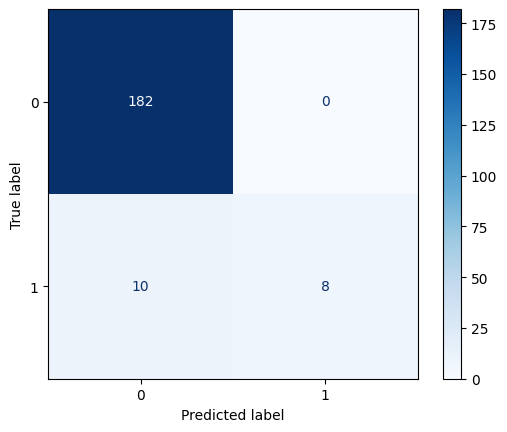

In [5]:
sentences = data["clean_text"]
runs = 1
zero_shot_scores = []

for run in range(runs):
    zero_shot_predictions = []

    for i in trange(len(sentences), desc="Zero-shot / one-shot"):
        sentence = sentences.iloc[i]
        pred = zero_shot(sentence)
        zero_shot_predictions.append(pred)

    export_zero_shot = evaluate_predictions(
        data,
        zero_shot_predictions,
        method_name="Zero-shot / one-shot annotation",
        true_col="afford_ed" # Changed from default 'aggro_human_rm'
    )
    zero_shot_scores.append(summarize_scores(export_zero_shot, "zero-shot / one-shot", true_col="afford_ed")) # Changed from default 'aggro_human_rm'

export_zero_shot.head()
export_zero_shot.to_csv("/content/zero_shot_afforded.csv", index=False)
